# exp-h0-component-complement-audit-01

H0 내부의 Selective-EB, non-EB, EB 및 동일 specialist 확률이 서로 보완되는지 보는 마지막 소폭 앙상블 감사입니다. 고정 0.5 평균만 비교하며 가중치 탐색·제출 생성은 하지 않습니다.

In [1]:
from pathlib import Path
import json, subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_011'
RUNNER = BASE / 'common' / 'run_h0_component_complement_audit.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-h0-component-complement-audit-01'
RUN_EXPERIMENT = True
assert (ROOT / 'data' / 'raw' / 'train.csv').exists()
assert RUNNER.exists()
print({'runner': RUNNER, 'test_read': False, 'fixed_blends': ['0.5/0.5']})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_011/common/run_h0_component_complement_audit.py'), 'test_read': False, 'fixed_blends': ['0.5/0.5']}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H0 component audit', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-100:]
    if process.wait() != 0:
        raise RuntimeError('component audit runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 기존 결과만 읽습니다.')

H0 component audit: 1line [00:05,  5.01s/line]

[H0 complement] fold 1/5: train-only H0 branches


H0 component audit: 2line [03:42, 129.77s/line]

[H0 complement] fold 1/5 checkpoint saved
[H0 complement] fold 2/5: train-only H0 branches


H0 component audit: 4line [07:51, 126.45s/line]

...

H0 component audit: 10line [19:48, 121.10s/line]

[H0 complement] fold 5/5 checkpoint saved


H0 component audit: 11line [19:49, 96.27s/line] 

{"run_id": "exp-h0-component-complement-audit-01", "h0_reference": 0.547915, "h0_reference_match": true, "h0_reference_delta": -3.387370274277046e-07, "test_read": false, "train_test_concat": false, "leakage_check": true, "nan_as_mutation_count": 0, "best_fixed_candidate": "equal_H0_non_EB", "best_delta_vs_h0": 0.0002292724079451247, "positive_fold_count": 3, "recovered_exceeds_broken": true, "low_margin_delta": -0.007533776508709761, "three_seed_candidate": false}


H0 component audit: 11line [19:49, 108.15s/line]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
overlap = pd.read_csv(RESULT / f'{RUN_ID}_seed42_error_overlap.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_audit.json').read_text())
assert summary.leakage_check.all()
assert summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False and audit['leakage_check'] is True
display(summary.sort_values('oof_macro_f1', ascending=False))
display(overlap.sort_values('h0_wrong_recovered', ascending=False))
audit

,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0,recovered_h0_errors,broken_h0_correct
3,equal_H0_non_EB,0.548144,0.559103,8219.2,0,True,0,1186.792286,0.000229,40,39
0,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,1186.715474,0.000000,0,0
4,equal_H0_EB,0.547417,0.559265,8219.2,0,True,0,1186.817232,-0.000498,25,23
1,H0_non_EB,0.544744,0.555556,8219.2,0,True,0,1186.741622,-0.003171,75,96
2,H0_EB,0.544730,0.558136,8219.2,0,True,0,1186.766810,-0.003184,45,50


,variant,hard_prediction_disagreement_rate,h0_wrong_recovered,h0_correct_broken
0,H0_non_EB,0.051766,75,96
1,H0_EB,0.030963,45,50
2,equal_H0_non_EB,0.025802,40,39
3,equal_H0_EB,0.016288,25,23


{'run_id': 'exp-h0-component-complement-audit-01',
 'h0_reference': 0.547915,
 'h0_reference_match': True,
 'h0_reference_delta': -3.387370274277046e-07,
 'test_read': False,
 'train_test_concat': False,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'best_fixed_candidate': 'equal_H0_non_EB',
 'best_delta_vs_h0': 0.0002292724079451247,
 'positive_fold_count': 3,
 'recovered_exceeds_broken': True,
 'low_margin_delta': -0.007533776508709761,
 'three_seed_candidate': False}

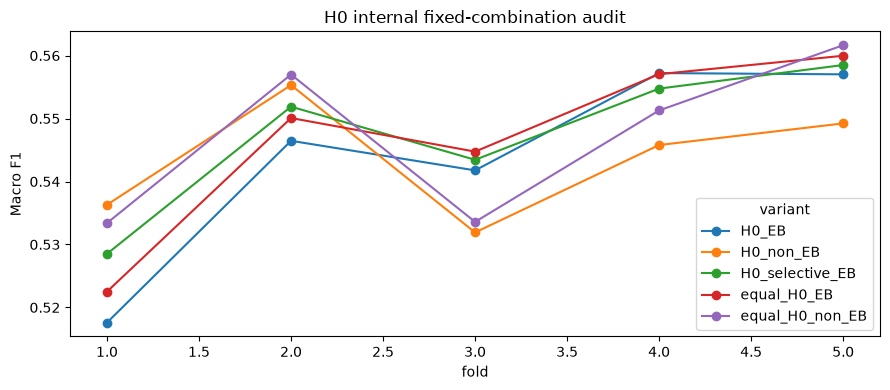

최고 fixed 후보: equal_H0_non_EB, Δ=+0.000229
3-seed 후보: False


In [4]:
folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', figsize=(9, 4), title='H0 internal fixed-combination audit')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
best = summary.loc[summary.variant.ne('H0_selective_EB')].sort_values('oof_macro_f1', ascending=False).iloc[0]
print(f"최고 fixed 후보: {best.variant}, Δ={best.delta_vs_h0:+.6f}")
print('3-seed 후보:', audit['three_seed_candidate'])